# Multi-seed revision results — coverage / success / baselines / compute

Generated for the **offline-replay + orbit-restart** sweep (`IDDPGWithoutS`,
`DiffDriveParallelEnvDone`, v_ang_max = pi/2, 1000 episodes, 5 seeds).

Consolidated quantitative evidence for the manuscript revision. Each section is
annotated with the reviewer concern it addresses.

**Data:** primary source is `run_details.csv` (per-run totals; ships locally in
`revision_logs/`). Episode-wise learning curves (§3) need `episode_summary.csv`
(media drive only) and self-skip otherwise.

| Reviewer point | Section |
|---|---|
| R1 single-seed / R2#14 (3-5 seeds + CI) | §2 table, §3 curves, §6 stats |
| R1 within-env baselines / R2#13 (extra ablation) | §2, §4 baseline; §4b MADDPG |
| R1 #14 return SD column | §2b |
| R1 #12/#16 completion-time + Kaplan–Meier | §5c |
| R1 reproducibility (net dims, reward weights) | §7 compute/repro, §8 reward map |
| R2#2 collision constant c=7 / R2#3 alpha mapping | §8 |
| R2#15 computational cost / generalization | §7 / §5b |

PNG + CSV → `<ROOT>/res/`; **all figure PDFs → `res/figures_pdf/`** (one dir).


In [1]:
import os, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Default: gitignored local light logs that ship with the repo (runnable as-is).
# Override with REVISION_ROOT to point at the media logs (for episode-wise curves)
# or the full artifact root.
_HERE  = os.path.dirname(os.path.abspath("__file__"))
_LOCAL = os.path.join(os.path.dirname(_HERE), "revision_logs")     # repo/revision_logs
ROOT = os.environ.get("REVISION_ROOT") or (_LOCAL if os.path.isdir(_LOCAL) else r"/home/abz/Desktop/dif_driven_revision_offline_replay_restart_v3_artifacts")
RUNS = os.path.join(ROOT, "runs")
RES  = os.path.join(ROOT, "res"); os.makedirs(RES, exist_ok=True)
# Vector PDFs of every figure go into ONE dedicated repo-level directory
# (repo/res/figures_pdf) regardless of ROOT — ready to drop into the manuscript.
_REPO = os.path.dirname(_HERE)
PDF  = os.path.join(_REPO, "res", "figures_pdf"); os.makedirs(PDF, exist_ok=True)
DETAILS = os.path.join(ROOT, "run_details.csv")

MODES = ["full", "ablation", "nocoll"]
NS    = [4, 5, 6]
SEEDS = [1, 2, 3, 4, 5]
WINDOW = 200
MODE_COLOR = {"full": "#1f77b4", "ablation": "#ff7f0e", "nocoll": "#2ca02c"}
print("ROOT:", ROOT)
assert os.path.exists(DETAILS), f"run_details.csv not found at {DETAILS} — run tools/export_light_logs.py"
HAS_EPISODEWISE = bool(glob.glob(os.path.join(RUNS, "*", "episode_summary.csv")))
print("episode-wise data present:", HAS_EPISODEWISE, "(needed only for §3 curves)")

ROOT: /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs
episode-wise data present: True (needed only for §3 curves)


## §1 Load per-run totals  *(from `run_details.csv`)*

One row per run: last-200 success rate, coverage, restarts, compute, and
last-200 per-component means.

In [2]:
per_run = pd.read_csv(DETAILS).sort_values(["n", "mode", "seed"]).reset_index(drop=True)
print(f"loaded {len(per_run)} runs")
per_run.head()

loaded 45 runs


,run,n,mode,seed,episodes,SR,coverage,comp1_mean,comp2_mean,comp3_mean,...,comp6_mean,comp7_mean,comp8_mean,comp9_mean,restarts,finished,train_hours,peak_gpu_gb,total_steps,gpu_name
0,n4_ablation_seed1,4,ablation,1,1000,100.0,100.0,0.0,0.0,0.0,...,-0.01,-20.26,-90.64,-119.50,0,True,2.328327,0.072824,225230,NVIDIA GeForce RTX 4050 Laptop GPU
1,n4_ablation_seed2,4,ablation,2,1000,93.0,98.2,0.0,0.0,0.0,...,-0.04,-25.79,-125.92,-158.78,0,True,2.543126,0.072836,251908,NVIDIA GeForce RTX 4050 Laptop GPU
2,n4_ablation_seed3,4,ablation,3,1000,96.0,99.0,0.0,0.0,0.0,...,-0.02,-22.45,-95.04,-128.58,0,True,2.483056,0.072585,228869,NVIDIA GeForce RTX 4050 Laptop GPU
3,n4_ablation_seed4,4,ablation,4,1000,98.0,99.5,0.0,0.0,0.0,...,-0.04,-22.30,-111.03,-145.06,0,True,2.694343,0.072585,250523,NVIDIA GeForce RTX 4050 Laptop GPU
4,n4_ablation_seed5,4,ablation,5,1000,98.0,99.5,0.0,0.0,0.0,...,-0.02,-13.06,-76.06,-106.28,1,True,3.781075,0.072836,211368,NVIDIA GeForce RTX 4050 Laptop GPU


## §2 Multi-seed summary table  *(R1 single-seed, R2#14)*

Last-200 success rate and coverage, mean ± SD over the 5 seeds, with per-seed SR
shown explicitly (never hide a seed in a mean).

In [3]:
def cell(group):
    return pd.Series({
        "seeds": group.shape[0],
        "SR_mean": round(group.SR.mean(), 1),
        "SR_sd": round(group.SR.std(ddof=0), 1),
        "cov_mean": round(group.coverage.mean(), 1),
        "cov_sd": round(group.coverage.std(ddof=0), 1),
        "SR_per_seed": ", ".join(f"{s}:{v}" for s, v in zip(group.seed, group.SR)),
    })
summary = per_run.groupby(["n", "mode"]).apply(cell).reset_index()
summary["SR (mean±SD)"]  = summary.SR_mean.map("{:.1f}".format)  + " ± " + summary.SR_sd.map("{:.1f}".format)
summary["cov (mean±SD)"] = summary.cov_mean.map("{:.1f}".format) + " ± " + summary.cov_sd.map("{:.1f}".format)
display(summary[["n", "mode", "seeds", "SR (mean±SD)", "cov (mean±SD)", "SR_per_seed"]])
summary.to_csv(os.path.join(RES, "revision_final_cell_summary.csv"), index=False)
print("overall by mode (SR mean ± SD):")
for mode in MODES:
    v = per_run[per_run["mode"] == mode].SR
    print(f"  {mode:<9}: {v.mean():5.1f} ± {v.std(ddof=0):4.1f}  (k={len(v)})")

,n,mode,seeds,SR (mean±SD),cov (mean±SD),SR_per_seed
0,4,ablation,5,97.0 ± 2.4,99.2 ± 0.6,"1:100.0, 2:93.0, 3:96.0, 4:98.0, 5:98.0"
1,4,full,5,98.2 ± 2.9,99.6 ± 0.7,"1:99.5, 2:99.5, 3:100.0, 4:99.5, 5:92.5"
2,4,nocoll,5,86.4 ± 21.8,96.4 ± 5.8,"1:100.0, 2:96.5, 3:93.0, 4:99.5, 5:43.0"
3,5,ablation,5,90.9 ± 4.9,98.2 ± 1.0,"1:90.0, 2:92.0, 3:91.0, 4:83.0, 5:98.5"
4,5,full,5,85.1 ± 18.0,96.7 ± 4.1,"1:49.5, 2:94.5, 3:98.5, 4:92.0, 5:91.0"
5,5,nocoll,5,96.5 ± 3.0,99.3 ± 0.6,"1:99.0, 2:98.0, 3:95.5, 4:99.0, 5:91.0"
6,6,ablation,5,89.6 ± 7.6,98.2 ± 1.3,"1:98.5, 2:93.0, 3:94.0, 4:85.5, 5:77.0"
7,6,full,5,96.3 ± 2.0,99.4 ± 0.3,"1:97.0, 2:92.5, 3:98.0, 4:96.5, 5:97.5"
8,6,nocoll,5,96.6 ± 1.2,99.4 ± 0.2,"1:95.0, 2:97.0, 3:98.0, 4:95.5, 5:97.5"


overall by mode (SR mean ± SD):
  full     :  93.2 ± 12.1  (k=15)
  ablation :  92.5 ±  6.3  (k=15)
  nocoll   :  93.2 ± 13.6  (k=15)


## §2b Episode return (scalar reward) mean ± SD  *(R1 #14)*

R1 #14 asks Table 2 to also report the **return spread (SD)**. The scalar episode
return is the last-200 mean of `sum_k alpha_k * comp_k` — the dot product of the
mode's reward weights (§8) with the per-component means. Reported as mean ± SD
across the 5 seeds per cell (population SD, ddof=0, matching §2).

The very wide SD at **n4-nocoll** and **n5-full** is driven by the two
orbit-failure seeds (n4_nocoll_s5, n5_full_s1) — the same outliers that widen the
SR SD (§9). Return tracks success: the healthy cells sit at +90…+225, the
outlier-dragged cells swing negative because the per-step time/direction penalties
accumulate over the long un-terminated orbit episodes.

In [4]:
SCALES = {"full": [1,1,0,10,10,10,1,1,1], "ablation": [0,0,0,10,10,10,1,1,1], "nocoll": [1,1,0,10,0,0,1,1,1]}
_comps = [f"comp{i}_mean" for i in range(1, 10)]
per_run["return"] = per_run.apply(lambda r: float(np.dot(r[_comps].values, SCALES[r["mode"]])), axis=1)
ret = (per_run.groupby(["n", "mode"])["return"]
       .agg(ret_mean="mean", ret_sd=lambda x: x.std(ddof=0)).round(1).reset_index())
ret["return (mean±SD)"] = ret.ret_mean.map("{:.1f}".format) + " ± " + ret.ret_sd.map("{:.1f}".format)
display(ret[["n", "mode", "return (mean±SD)"]])
ret.to_csv(os.path.join(RES, "revision_return_summary.csv"), index=False)
print("overall return by mode (mean ± SD):")
for mode in MODES:
    v = per_run[per_run["mode"] == mode]["return"]
    print(f"  {mode:<9}: {v.mean():7.1f} ± {v.std(ddof=0):6.1f}")

,n,mode,return (mean±SD)
0,4,ablation,144.4 ± 41.3
1,4,full,181.0 ± 62.8
2,4,nocoll,-21.9 ± 387.0
3,5,ablation,102.7 ± 74.4
4,5,full,-32.1 ± 329.7
5,5,nocoll,169.7 ± 62.6
6,6,ablation,91.3 ± 128.1
7,6,full,216.8 ± 43.8
8,6,nocoll,224.1 ± 18.7


overall return by mode (mean ± SD):
  full     :   121.9 ±  224.2
  ablation :   112.8 ±   91.7
  nocoll   :   124.0 ±  250.0


## §3 Learning curves with shaded ±SD across seeds  *(R1 §3.1 / §3.2)*

Rolling success / coverage (50-ep window) averaged across seeds with a ±1 SD
band. Uses the compact per-episode `episode_summary.csv` (ships locally). If
absent, this cell skips and points to the pre-rendered PNGs.

saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_rolling_success_full_valid.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_rolling_success_full_valid.pdf


saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_rolling_coverage_full_valid.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_rolling_coverage_full_valid.pdf


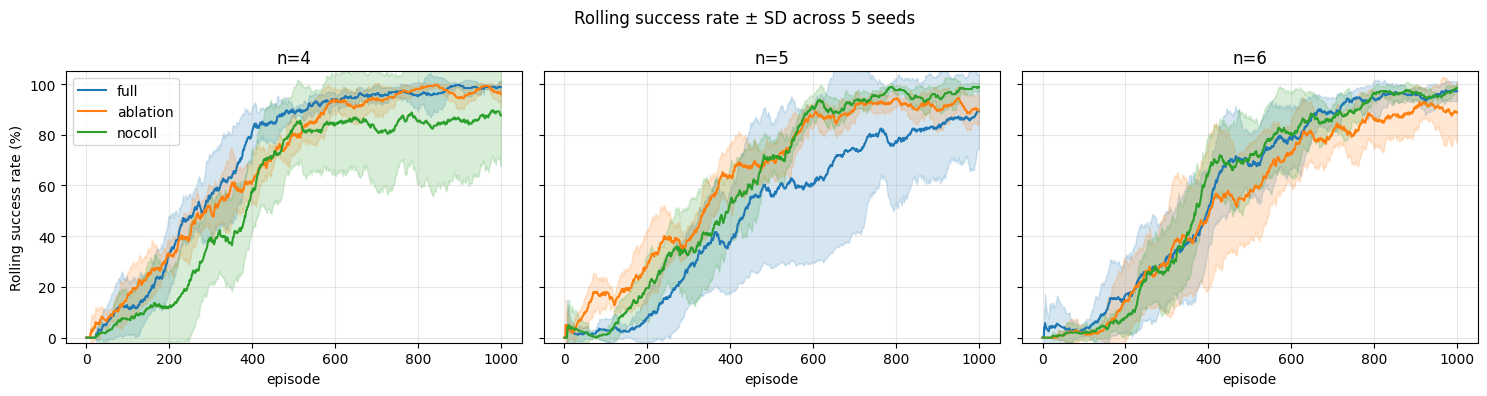

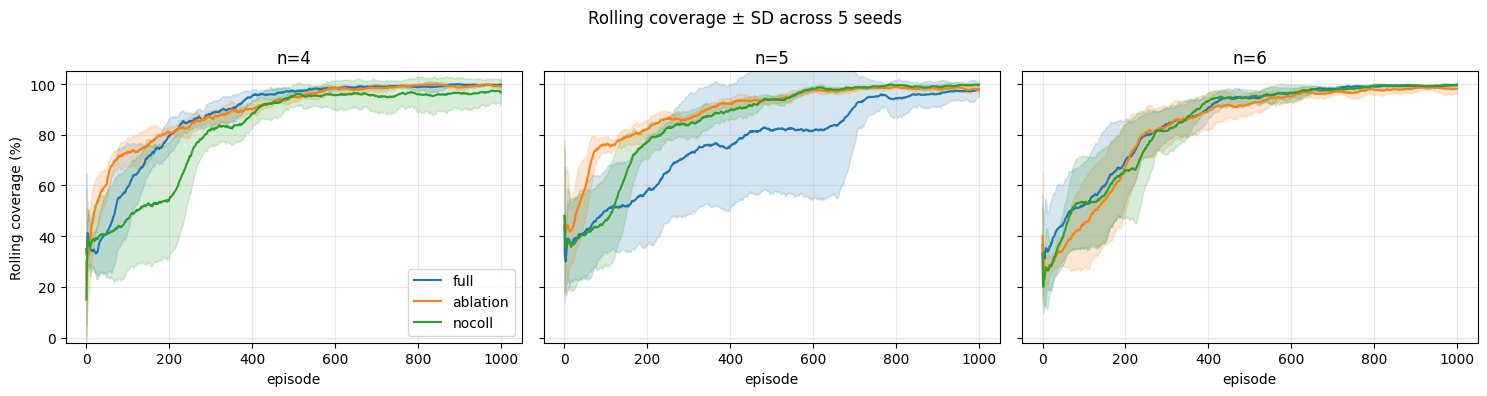

In [5]:
def episode_series(n, mode, seed):
    p = os.path.join(RUNS, f"n{n}_{mode}_seed{seed}", "episode_summary.csv")
    if not os.path.exists(p): return None
    s = pd.read_csv(p).sort_values("episode_id")
    return s.done_count.to_numpy() / n, (s.done_count.to_numpy() >= n).astype(float)

def rolling(x, w=50):
    return pd.Series(x).rolling(w, min_periods=1).mean().to_numpy()

if not HAS_EPISODEWISE:
    print("episode-wise data not present locally — curves are media-only.")
    for m in ("success", "coverage"):
        print("  pre-rendered:", os.path.join(RES, f"revision_rolling_{m}_full_valid.png"))
else:
    for metric, idx, title in [("success", 1, "Rolling success rate"), ("coverage", 0, "Rolling coverage")]:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
        for ax, n in zip(axes, NS):
            for mode in MODES:
                curves = []
                for seed in SEEDS:
                    es = episode_series(n, mode, seed)
                    if es is not None: curves.append(rolling(es[idx]))
                if not curves: continue
                L = min(len(c) for c in curves); M = np.vstack([c[:L] for c in curves])
                mean, sd = 100 * M.mean(0), 100 * M.std(0, ddof=0)
                ax.plot(np.arange(L), mean, color=MODE_COLOR[mode], label=mode)
                ax.fill_between(np.arange(L), mean - sd, mean + sd, color=MODE_COLOR[mode], alpha=0.18)
            ax.set_title(f"n={n}"); ax.set_xlabel("episode"); ax.grid(alpha=0.3); ax.set_ylim(-2, 105)
        axes[0].set_ylabel(f"{title} (%)"); axes[0].legend()
        fig.suptitle(f"{title} ± SD across {len(SEEDS)} seeds"); fig.tight_layout()
        out = os.path.join(RES, f"revision_rolling_{metric}_full_valid")
        fig.savefig(out + ".png", dpi=130, bbox_inches="tight")
        fig.savefig(os.path.join(PDF, os.path.basename(out) + ".pdf"), bbox_inches="tight"); print("saved", out + ".png +", os.path.join(PDF, os.path.basename(out)+".pdf"))
    plt.show()

## §4 Baseline comparison bar charts  *(R1 baselines, R2#13)*

Final-window **success rate** and **coverage** per n, grouped by reward mode.
Both metrics plotted (one chart each). Error bars ±1 SD across seeds.

saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_baseline_success_valid.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_baseline_success_valid.pdf
saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_baseline_coverage_valid.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_baseline_coverage_valid.pdf


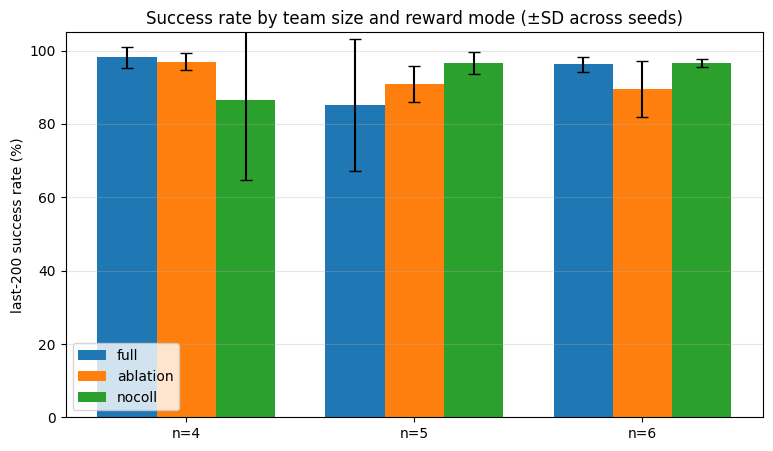

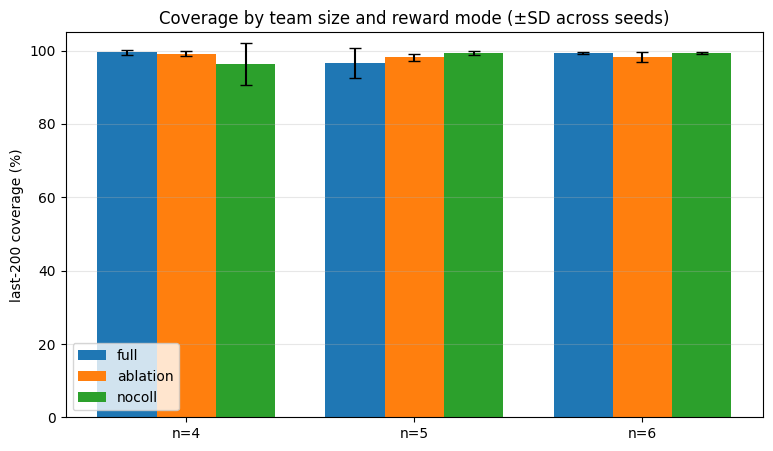

In [6]:
for metric, mcol, scol, title, fname in [
        ("success rate", "SR_mean", "SR_sd", "Success rate", "revision_baseline_success_valid"),
        ("coverage",     "cov_mean", "cov_sd", "Coverage",     "revision_baseline_coverage_valid")]:
    fig, ax = plt.subplots(figsize=(9, 5))
    width = 0.26; x = np.arange(len(NS))
    for i, mode in enumerate(MODES):
        means = [summary[(summary.n == n) & (summary["mode"] == mode)][mcol].values[0] for n in NS]
        sds   = [summary[(summary.n == n) & (summary["mode"] == mode)][scol].values[0] for n in NS]
        ax.bar(x + (i - 1) * width, means, width, yerr=sds, capsize=4, color=MODE_COLOR[mode], label=mode)
    ax.set_xticks(x); ax.set_xticklabels([f"n={n}" for n in NS])
    ax.set_ylabel(f"last-200 {metric} (%)"); ax.set_ylim(0, 105)
    ax.set_title(f"{title} by team size and reward mode (±SD across seeds)")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    out = os.path.join(RES, fname)
    fig.savefig(out + ".png", dpi=130, bbox_inches="tight")
    fig.savefig(os.path.join(PDF, os.path.basename(out) + ".pdf"), bbox_inches="tight"); print("saved", out + ".png +", os.path.join(PDF, os.path.basename(out)+".pdf"))
plt.show()

## §4b MADDPG within-environment baseline  *(R1 #2 / #17)*

Lowe-2017-style joint-action **centralized-critic** MADDPG (fixed CTDE variant
`maddpg_obs` = `MADDPGSharedActorCriticIndependentObs`), run through the **same
pipeline** (offline relabeling, full reward `[1,1,0,10,10,10,1,1,1]`, π/2,
num_obstacles=0, env_size=20) **without** the orbit-restart controller, on the
matched seeds {1,2,3}. Same last-200 window as the proposed method (fair).

The original `--algorithm maddpg` was broken (3 bugs: reward-mask A, joint-action
credit assignment B, state/action ordering C); `maddpg_obs` fixes A+B and
conditions the critic on **concatenated per-agent obs in index order** (fixes C).
Full writeup: `.ai/experiment_conclusions.md` §13.

**Reporting decision (§13.3): report BOTH SR and coverage — do NOT suppress SR.**
MADDPG attains *partial* success that **degrades with team size** and stays far
below the proposed ≥93%: joint-action critic credit assignment weakens as N grows
(cf. VDN/QMIX/COMA). One seed per n collapses to the chance floor (~25–30% cov,
0% SR) — disclosed per-seed, never averaged away.

Auto-loads the MADDPG `run_details.csv` from `revision_logs_maddpg_obs/`
(override with `MADDPG_ROOT`); standalone table + head-to-head + bars + curves.

In [7]:
maddpg_root = os.environ.get("MADDPG_ROOT") or \
    os.path.join(os.path.dirname(_HERE), "revision_logs_maddpg_obs")
maddpg_csv = os.path.join(maddpg_root, "run_details.csv")
HAS_MADDPG = os.path.exists(maddpg_csv)
if not HAS_MADDPG:
    print("MADDPG baseline results NOT FOUND at", maddpg_csv)
    print("  export: python tools/export_light_logs.py \\")
    print("    --artifact_root <maddpg_artifact_root> --local_logs revision_logs_maddpg_obs --window 200")
else:
    mad = pd.read_csv(maddpg_csv)
    print(f"MADDPG loaded: {len(mad)} runs from {maddpg_root}")
    # --- standalone per-n table: mean ± SD over seeds, SR & coverage, per-seed SR/cov ---
    tbl = []
    for n in NS:
        sub = mad[mad.n == n]
        if not len(sub): continue
        tbl.append(dict(n=n, seeds=len(sub),
            SR=f"{sub.SR.mean():.1f} ± {sub.SR.std(ddof=0):.1f}",
            coverage=f"{sub.coverage.mean():.1f} ± {sub.coverage.std(ddof=0):.1f}",
            SR_per_seed=", ".join(f"{s}:{v}" for s, v in zip(sub.seed, sub.SR)),
            cov_per_seed=", ".join(f"{s}:{v}" for s, v in zip(sub.seed, sub.coverage))))
    display(pd.DataFrame(tbl))

MADDPG loaded: 9 runs from /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs_maddpg_obs


,n,seeds,SR,coverage,SR_per_seed,cov_per_seed
0,4,3,14.8 ± 10.5,58.2 ± 22.6,"1:21.5, 2:23.0, 3:0.0","1:73.2, 2:75.1, 3:26.2"
1,5,3,0.0 ± 0.0,29.0 ± 1.1,"1:0.0, 2:0.0, 3:0.0","1:28.7, 2:27.8, 3:30.4"
2,6,3,10.7 ± 7.4,62.2 ± 22.7,"1:13.5, 2:18.0, 3:0.5","1:75.2, 2:81.2, 3:30.3"


In [8]:
if HAS_MADDPG:
    # --- head-to-head vs proposed (full) on shared seeds ---
    shared = sorted(set(mad.seed) & set(per_run.seed))
    ours = per_run[(per_run["mode"] == "full") & (per_run.seed.isin(shared))]
    mads = mad[mad.seed.isin(shared)]
    print(f"Head-to-head on shared seeds {shared}: proposed (full) vs MADDPG")
    cmp = []
    for n in NS:
        o = ours[ours.n == n].SR; m = mads[mads.n == n].SR
        oc = ours[ours.n == n].coverage; mc = mads[mads.n == n].coverage
        cmp.append(dict(n=n,
            proposed_SR=f"{o.mean():.1f} ± {o.std(ddof=0):.1f}" if len(o) else "—",
            MADDPG_SR=f"{m.mean():.1f} ± {m.std(ddof=0):.1f}" if len(m) else "—",
            proposed_cov=f"{oc.mean():.1f} ± {oc.std(ddof=0):.1f}" if len(oc) else "—",
            MADDPG_cov=f"{mc.mean():.1f} ± {mc.std(ddof=0):.1f}" if len(mc) else "—",
            MADDPG_SR_per_seed=", ".join(f"{s}:{v}" for s, v in zip(mads[mads.n==n].seed, m))))
    cmpdf = pd.DataFrame(cmp); display(cmpdf)
    cmpdf.to_csv(os.path.join(RES, "revision_maddpg_vs_proposed.csv"), index=False)

Head-to-head on shared seeds [1, 2, 3]: proposed (full) vs MADDPG


,n,proposed_SR,MADDPG_SR,proposed_cov,MADDPG_cov,MADDPG_SR_per_seed
0,4,99.7 ± 0.2,14.8 ± 10.5,99.9 ± 0.0,58.2 ± 22.6,"1:21.5, 2:23.0, 3:0.0"
1,5,80.8 ± 22.2,0.0 ± 0.0,95.7 ± 5.1,29.0 ± 1.1,"1:0.0, 2:0.0, 3:0.0"
2,6,95.8 ± 2.4,10.7 ± 7.4,99.3 ± 0.4,62.2 ± 22.7,"1:13.5, 2:18.0, 3:0.5"


saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_maddpg_baseline.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_maddpg_baseline.pdf


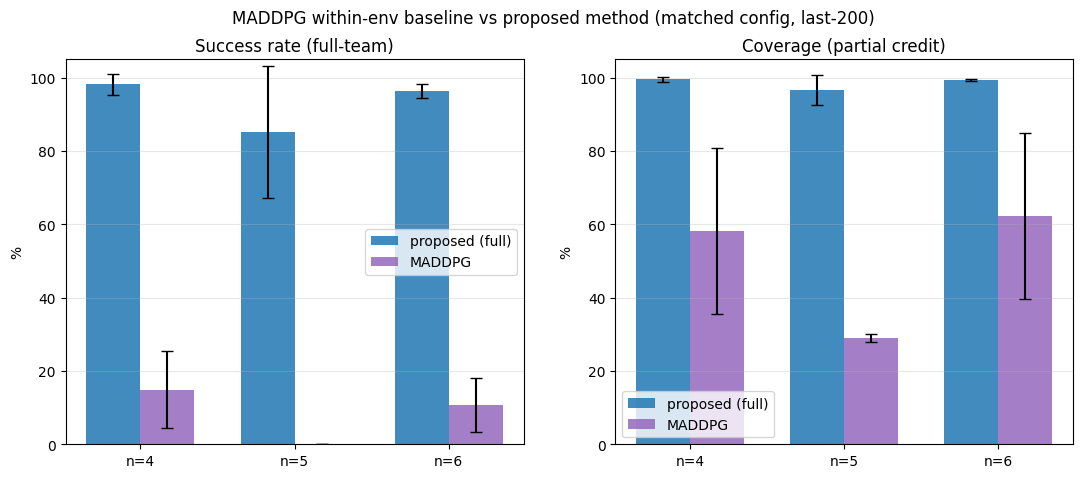

In [9]:
if HAS_MADDPG:
    # --- grouped bars: proposed (full) vs MADDPG, SR and coverage per n (±SD over seeds) ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    width = 0.35; x = np.arange(len(NS))
    for ax, (col, title) in zip(axes, [("SR", "Success rate (full-team)"),
                                       ("coverage", "Coverage (partial credit)")]):
        op = per_run[per_run["mode"] == "full"]
        om = [op[op.n == n][col].mean() for n in NS]; os_ = [op[op.n == n][col].std(ddof=0) for n in NS]
        mm = [mad[mad.n == n][col].mean() for n in NS]; ms = [mad[mad.n == n][col].std(ddof=0) for n in NS]
        ax.bar(x - width/2, om, width, yerr=os_, capsize=4, label="proposed (full)", color="#1f77b4", alpha=0.85)
        ax.bar(x + width/2, mm, width, yerr=ms, capsize=4, label="MADDPG", color="#9467bd", alpha=0.85)
        ax.set_xticks(x); ax.set_xticklabels([f"n={n}" for n in NS])
        ax.set_ylim(0, 105); ax.set_ylabel("%"); ax.set_title(title); ax.grid(axis="y", alpha=0.3); ax.legend()
    fig.suptitle("MADDPG within-env baseline vs proposed method (matched config, last-200)")
    out = os.path.join(RES, "revision_maddpg_baseline")
    fig.savefig(out + ".png", dpi=130, bbox_inches="tight")
    fig.savefig(os.path.join(PDF, os.path.basename(out) + ".pdf"), bbox_inches="tight"); print("saved", out + ".png +", os.path.join(PDF, os.path.basename(out)+".pdf"))
    plt.show()

saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_maddpg_curves.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_maddpg_curves.pdf


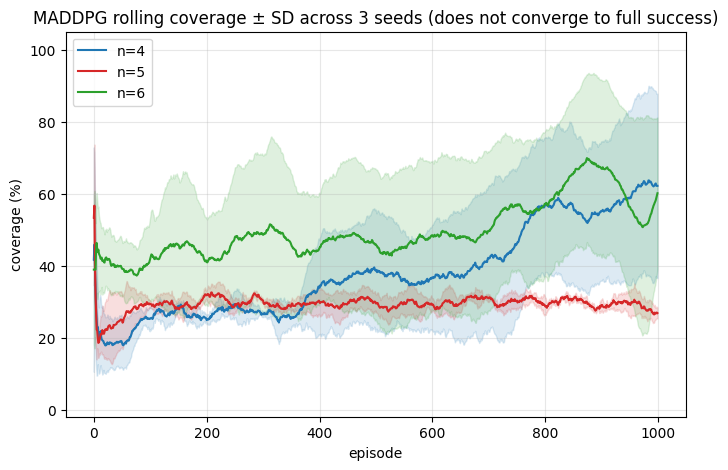

In [10]:
if HAS_MADDPG:
    # --- MADDPG learning curves (rolling coverage, ±SD across seeds) from episode_summary.csv ---
    mruns = os.path.join(maddpg_root, "runs")
    def maddpg_series(n, seed):
        for nm in (f"maddpg_obs_n{n}_full_seed{seed}", f"n{n}_full_seed{seed}"):
            p = os.path.join(mruns, nm, "episode_summary.csv")
            if os.path.exists(p):
                s = pd.read_csv(p).sort_values("episode_id")
                return s.done_count.to_numpy() / n
        return None
    if glob.glob(os.path.join(mruns, "*", "episode_summary.csv")):
        fig, ax = plt.subplots(figsize=(8, 5))
        cmap = {4: "#1f77b4", 5: "#d62728", 6: "#2ca02c"}
        for n in NS:
            curves = [rolling(s) for seed in (1, 2, 3) if (s := maddpg_series(n, seed)) is not None]
            if not curves: continue
            L = min(len(c) for c in curves); M = np.vstack([c[:L] for c in curves])
            mean, sd = 100 * M.mean(0), 100 * M.std(0, ddof=0)
            ax.plot(np.arange(L), mean, color=cmap[n], label=f"n={n}")
            ax.fill_between(np.arange(L), mean - sd, mean + sd, color=cmap[n], alpha=0.15)
        ax.set_xlabel("episode"); ax.set_ylabel("coverage (%)"); ax.set_ylim(-2, 105)
        ax.set_title("MADDPG rolling coverage ± SD across 3 seeds (does not converge to full success)")
        ax.legend(); ax.grid(alpha=0.3)
        out = os.path.join(RES, "revision_maddpg_curves")
        fig.savefig(out + ".png", dpi=130, bbox_inches="tight")
        fig.savefig(os.path.join(PDF, os.path.basename(out) + ".pdf"), bbox_inches="tight"); print("saved", out + ".png +", os.path.join(PDF, os.path.basename(out)+".pdf"))
        plt.show()
    else:
        print("MADDPG episode_summary.csv not present — skipping curves (table/bars above still valid).")

## §5 Coverage vs success scatter — partial-credit view

Several seeds reach high *coverage* even when full-team *success* is partial
(orbit / late-bootstrap). Reporting coverage separately from SR is the honest
framing for the high-variance cells.

saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_coverage_vs_success_scatter.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_coverage_vs_success_scatter.pdf


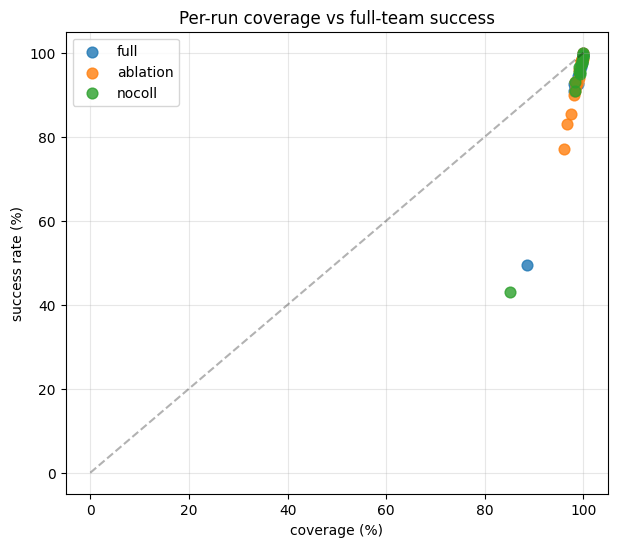

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for mode in MODES:
    sub = per_run[per_run["mode"] == mode]
    ax.scatter(sub.coverage, sub.SR, color=MODE_COLOR[mode], label=mode, s=60, alpha=0.8)
ax.plot([0, 100], [0, 100], "k--", alpha=0.3)
ax.set_xlabel("coverage (%)"); ax.set_ylabel("success rate (%)")
ax.set_title("Per-run coverage vs full-team success"); ax.legend(); ax.grid(alpha=0.3)
out = os.path.join(RES, "revision_coverage_vs_success_scatter")
fig.savefig(out + ".png", dpi=130, bbox_inches="tight")
fig.savefig(os.path.join(PDF, os.path.basename(out) + ".pdf"), bbox_inches="tight"); print("saved", out + ".png +", os.path.join(PDF, os.path.basename(out)+".pdf"))
plt.show()

## §5b Deterministic eval: generalization (env20→env25) + heuristic oracle  *(R2#15, R1#2)*

Noise-free policy rollouts (eval seed 42, 200 episodes) of the trained actors,
evaluated at the **training arena (env_size=20)** and a **25%-larger unseen arena
(env_size=25)**, plus a non-learning **Hungarian + P-controller oracle** at π/2.

Two metrics are reported throughout:
- **SR** — full-team success (all agents reached a goal).
- **coverage** — PARTIAL-success metric (mean fraction of agents that covered a
  landmark). Where SR dips, coverage stays high → the policy is *one agent short*,
  not failing. This is the honest reading of the high-variance cells.

Loads `revision_logs/eval/eval_summary.csv` + `eval_per_run.csv`
(produced by `tools/aggregate_eval.py`); self-skips with a note if absent.

In [12]:
EVAL_DIR = os.path.join(ROOT, "eval")
eval_summary_csv = os.path.join(EVAL_DIR, "eval_summary.csv")
eval_per_run_csv = os.path.join(EVAL_DIR, "eval_per_run.csv")
HAS_EVAL = os.path.exists(eval_summary_csv) and os.path.exists(eval_per_run_csv)
if not HAS_EVAL:
    print("Eval results NOT available — run:")
    print("  python tools/aggregate_eval.py --eval_dir <eval_dir> --out_dir revision_logs/eval")
else:
    ev = pd.read_csv(eval_summary_csv)
    evr = pd.read_csv(eval_per_run_csv)
    ev["SR (mean±SD)"]  = ev.SR_mean.map("{:.1f}".format)  + " ± " + ev.SR_sd.map("{:.1f}".format)
    ev["cov (mean±SD)"] = ev.cov_mean.map("{:.1f}".format) + " ± " + ev.cov_sd.map("{:.1f}".format)

    print("=== Learned policy — generalization (SR = full success, coverage = partial) ===")
    pol = ev[ev.kind == "policy"].sort_values(["env", "n"])
    display(pol[["env", "n", "SR (mean±SD)", "cov (mean±SD)",
                 "compT_mean", "coll_mean", "path_mean", "SR_per_seed"]])

    print("=== Heuristic oracle (Hungarian + P-controller, π/2, env20) ===")
    heu = ev[ev.kind == "heuristic"].sort_values("n")
    display(heu[["env", "n", "SR (mean±SD)", "cov (mean±SD)",
                 "compT_mean", "coll_mean", "path_mean"]])

    ev.to_csv(os.path.join(RES, "revision_eval_summary.csv"), index=False)

=== Learned policy — generalization (SR = full success, coverage = partial) ===


,env,n,SR (mean±SD),cov (mean±SD),compT_mean,coll_mean,path_mean,SR_per_seed
3,20,4,92.8 ± 6.0,98.2 ± 1.5,54.3,1.56,124.0,"1:98, 2:93, 3:94, 4:98, 5:82"
4,20,5,69.9 ± 32.4,90.1 ± 14.1,89.0,1.62,366.1,"1:6, 2:94, 3:88, 4:85, 5:77"
5,20,6,89.9 ± 6.9,98.3 ± 1.1,74.0,2.63,186.8,"1:86, 2:78, 3:97, 4:94, 5:94"
6,25,4,84.1 ± 11.8,95.7 ± 3.1,82.1,1.27,212.9,"1:94, 2:86, 3:86, 4:93, 5:62"
7,25,5,55.7 ± 27.9,85.0 ± 16.8,107.2,1.54,533.1,"1:4, 2:75, 3:82, 4:66, 5:52"
8,25,6,71.4 ± 8.5,95.0 ± 1.5,121.6,1.85,345.7,"1:71, 2:64, 3:84, 4:62, 5:76"


=== Heuristic oracle (Hungarian + P-controller, π/2, env20) ===


,env,n,SR (mean±SD),cov (mean±SD),compT_mean,coll_mean,path_mean
0,20,4,100.0 ± 0.0,100.0 ± 0.0,10.0,0.38,27.3
1,20,5,100.0 ± 0.0,100.0 ± 0.0,10.3,0.86,33.8
2,20,6,100.0 ± 0.0,100.0 ± 0.0,10.5,0.97,39.1


saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_eval_generalization.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_eval_generalization.pdf


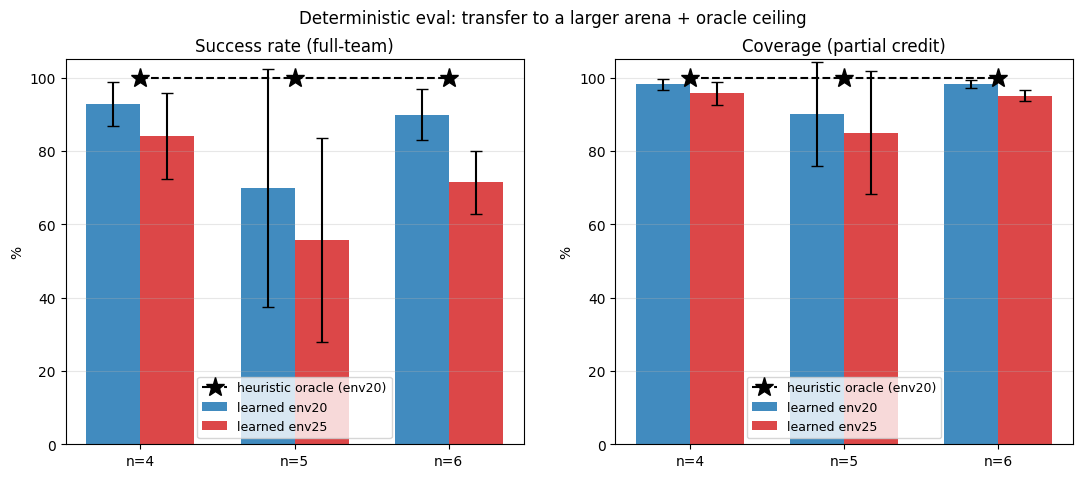

In [13]:
if HAS_EVAL:
    # Grouped bars: SR and coverage per n, env20 vs env25, with the oracle ceiling.
    pol = ev[ev.kind == "policy"]
    heu = ev[ev.kind == "heuristic"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    width = 0.35
    for ax, (mcol, scol, title) in zip(axes, [
            ("SR_mean", "SR_sd", "Success rate (full-team)"),
            ("cov_mean", "cov_sd", "Coverage (partial credit)")]):
        x = np.arange(len(NS))
        for k, (env, off, c) in enumerate([(20, -width/2, "#1f77b4"), (25, width/2, "#d62728")]):
            sub = pol[pol.env == env].set_index("n").reindex(NS)
            ax.bar(x + off, sub[mcol], width, yerr=sub[scol], capsize=4,
                   label=f"learned env{env}", color=c, alpha=0.85)
        ho = heu.set_index("n").reindex(NS)[mcol]
        ax.plot(x, ho.values, "k*--", ms=14, label="heuristic oracle (env20)")
        ax.set_xticks(x); ax.set_xticklabels([f"n={n}" for n in NS])
        ax.set_ylim(0, 105); ax.set_ylabel("%"); ax.set_title(title)
        ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=9)
    fig.suptitle("Deterministic eval: transfer to a larger arena + oracle ceiling")
    out = os.path.join(RES, "revision_eval_generalization")
    fig.savefig(out + ".png", dpi=130, bbox_inches="tight")
    fig.savefig(os.path.join(PDF, os.path.basename(out) + ".pdf"), bbox_inches="tight"); print("saved", out + ".png +", os.path.join(PDF, os.path.basename(out)+".pdf"))
    plt.show()

saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_eval_cov_vs_sr.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_eval_cov_vs_sr.pdf


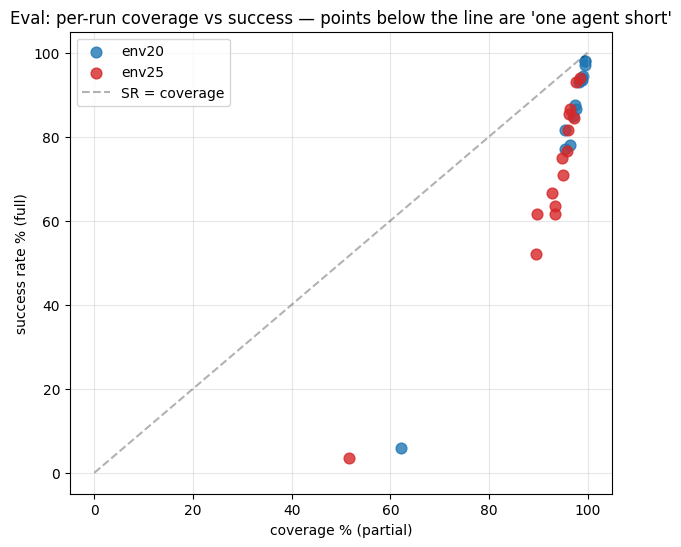

In [14]:
if HAS_EVAL:
    # Partial-credit highlight: SR vs coverage per run (env25), gap = shortfall.
    fig, ax = plt.subplots(figsize=(7, 6))
    for env, c in [(20, "#1f77b4"), (25, "#d62728")]:
        sub = evr[(evr.kind == "policy") & (evr.env == env)]
        ax.scatter(sub.coverage, sub.SR, color=c, s=60, alpha=0.8, label=f"env{env}")
    ax.plot([0, 100], [0, 100], "k--", alpha=0.3, label="SR = coverage")
    ax.set_xlabel("coverage % (partial)"); ax.set_ylabel("success rate % (full)")
    ax.set_title("Eval: per-run coverage vs success — points below the line are 'one agent short'")
    ax.legend(); ax.grid(alpha=0.3)
    out = os.path.join(RES, "revision_eval_cov_vs_sr")
    fig.savefig(out + ".png", dpi=130, bbox_inches="tight")
    fig.savefig(os.path.join(PDF, os.path.basename(out) + ".pdf"), bbox_inches="tight"); print("saved", out + ".png +", os.path.join(PDF, os.path.basename(out)+".pdf"))
    plt.show()

## §5c Completion time & Kaplan–Meier survival  *(R1 #12, #14, #16)*

Time-to-full-team-success from the deterministic eval episodes
(`eval_episodes.csv`). For each episode the **event** is full-team success at
`completion_time` (steps); episodes that never succeed are **right-censored** at
the 500-step horizon. This yields two things the reviewers asked for:

- **Completion-time distribution** of successful episodes — mean ± SD and median
  (R1 #14: report the spread). **This reconciles R1 #16**: the true median
  time-to-success is **~37–55 steps** at the training arena (env20), far inside
  the 500-step horizon — *not* the "≈280" figure the discussion quoted. SR
  (≈90–93%) and completion time are orthogonal axes and are now reported as such;
  the ≈280 came from mixing the two. The heuristic oracle completes in ~10 steps.
- **Kaplan–Meier survival curves** S(t) = P(team not yet fully covered by step t),
  pooled across the 5 seeds, per n, env20 vs env25 (event = success, censored at
  500). Each curve plateaus at **1 − SR** (the never-completed fraction); the
  median completion time is where it crosses 0.5. The KM estimator handles the
  censored failures correctly, so the curve is an honest time-to-success summary
  rather than a successes-only average.

In [15]:
if not HAS_EVAL:
    print("eval episodes not available — skipping completion-time / KM (R1 #12/#16)")
else:
    epi = pd.read_csv(os.path.join(EVAL_DIR, "eval_episodes.csv"))
    HORIZON = 500.0
    rows = []
    for (kind, env, n), sub in epi.groupby(["kind", "env", "n"]):
        succ = sub[sub.success == 1].completion_time
        rows.append(dict(kind=kind, env=int(env), n=int(n), episodes=len(sub),
            SR=round(100 * sub.success.mean(), 1),
            compT_mean=round(succ.mean(), 1), compT_sd=round(succ.std(ddof=0), 1),
            compT_median=round(succ.median(), 1)))
    compt = pd.DataFrame(rows).sort_values(["kind", "env", "n"]).reset_index(drop=True)
    print("Completion time (steps) of SUCCESSFUL episodes; SR shown for context:")
    display(compt)
    compt.to_csv(os.path.join(RES, "revision_completion_time.csv"), index=False)

Completion time (steps) of SUCCESSFUL episodes; SR shown for context:


,kind,env,n,episodes,SR,compT_mean,compT_sd,compT_median
0,heuristic,20,4,200,100.0,10.0,2.2,10.0
1,heuristic,20,5,200,100.0,10.3,2.5,10.0
2,heuristic,20,6,200,100.0,10.5,2.2,10.0
3,policy,20,4,1000,92.8,53.8,59.3,37.0
4,policy,20,5,1000,69.9,75.8,78.2,49.0
5,policy,20,6,1000,89.9,74.1,74.1,51.0
6,policy,25,4,1000,84.1,82.2,76.4,56.0
7,policy,25,5,1000,55.7,108.4,96.0,73.0
8,policy,25,6,1000,71.4,123.5,109.2,78.5


saved /home/abz/workspace/PycharmProjects/dif_driven_maddpg/revision_logs/res/revision_km_completion.png + /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/revision_km_completion.pdf


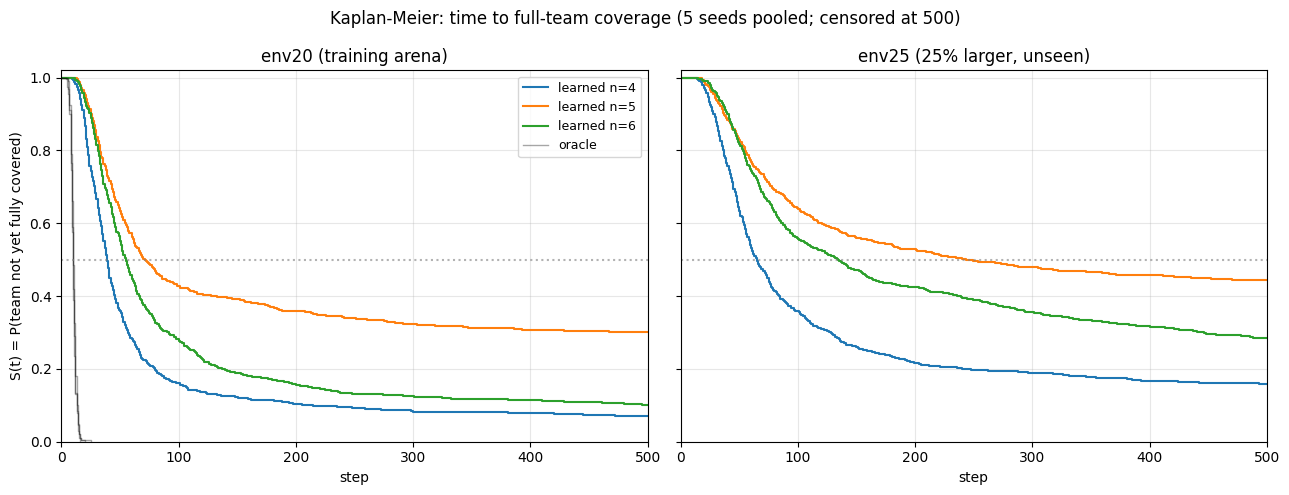

In [16]:
def km_curve(times, events, horizon=500.0):
    """Kaplan-Meier survival S(t)=P(not yet completed). times NaN -> censored at horizon."""
    t = np.where(np.isnan(times), horizon, times).astype(float)
    d = np.asarray(events, dtype=int)
    order = np.argsort(t); t, d = t[order], d[order]
    xs, ys, S = [0.0], [1.0], 1.0
    for tt in np.unique(t):
        risk = int((t >= tt).sum()); ev = int(((t == tt) & (d == 1)).sum())
        if risk > 0 and ev > 0:
            S *= (1 - ev / risk)
        xs.append(float(tt)); ys.append(S)
    return np.array(xs), np.array(ys)

if HAS_EVAL:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    NCOLOR = {4: "#1f77b4", 5: "#ff7f0e", 6: "#2ca02c"}
    for ax, env in zip(axes, [20, 25]):
        for n in NS:
            sub = epi[(epi.kind == "policy") & (epi.env == env) & (epi.n == n)]
            if sub.empty: continue
            xs, ys = km_curve(sub.completion_time.values, sub.success.values)
            ax.step(xs, ys, where="post", color=NCOLOR[n], label=f"learned n={n}")
        if env == 20:  # oracle reference, env20 only
            for n in NS:
                sub = epi[(epi.kind == "heuristic") & (epi.env == env) & (epi.n == n)]
                if sub.empty: continue
                xs, ys = km_curve(sub.completion_time.values, sub.success.values)
                ax.step(xs, ys, where="post", color="k", alpha=0.35, lw=1,
                        label="oracle" if n == NS[0] else None)
        ax.axhline(0.5, color="gray", ls=":", alpha=0.6)
        ax.set_title(f"env{env}" + (" (training arena)" if env == 20 else " (25% larger, unseen)"))
        ax.set_xlabel("step"); ax.set_xlim(0, 500); ax.grid(alpha=0.3)
    axes[0].set_ylabel("S(t) = P(team not yet fully covered)")
    axes[0].set_ylim(0, 1.02); axes[0].legend(fontsize=9)
    fig.suptitle("Kaplan-Meier: time to full-team coverage (5 seeds pooled; censored at 500)")
    fig.tight_layout()
    out = os.path.join(RES, "revision_km_completion")
    fig.savefig(out + ".png", dpi=130, bbox_inches="tight")
    fig.savefig(os.path.join(PDF, os.path.basename(out) + ".pdf"), bbox_inches="tight"); print("saved", out + ".png +", os.path.join(PDF, os.path.basename(out)+".pdf"))
    plt.show()

## §6 Seed-level statistics  *(R2#14 / plan §2.5)*

Kruskal–Wallis across modes per n; Mann–Whitney full-vs-baselines (pooled);
bootstrap 95% CI of mean per cell (per-seed resampling). **Run for both
success rate and coverage.**

In [17]:
try:
    from scipy import stats
    for METRIC in ["SR", "coverage"]:
        col = per_run[METRIC]
        print("=" * 64)
        print(f"METRIC: {METRIC}")
        print("=" * 64)
        print("Kruskal-Wallis across modes (per n):")
        for n in NS:
            groups = [per_run[(per_run.n == n) & (per_run["mode"] == m)][METRIC].values for m in MODES]
            if all(len(g) > 0 for g in groups):
                H, p = stats.kruskal(*groups)
                print(f"  n={n}: H={H:.3f}, p={p:.3f}")
        print("\nMann-Whitney U (pooled over n):")
        for a, b in [("full", "nocoll"), ("full", "ablation")]:
            va = per_run[per_run["mode"] == a][METRIC].values
            vb = per_run[per_run["mode"] == b][METRIC].values
            U, p = stats.mannwhitneyu(va, vb, alternative="two-sided")
            print(f"  {a} vs {b}: U={U:.1f}, p={p:.3f}  (median {np.median(va):.1f} vs {np.median(vb):.1f})")
        print(f"\nBootstrap 95% CI of mean {METRIC} per cell:")
        for n in NS:
            for mode in MODES:
                v = per_run[(per_run.n == n) & (per_run["mode"] == mode)][METRIC].values
                if len(v) < 2: continue
                res = stats.bootstrap((v,), np.mean, confidence_level=0.95, n_resamples=5000)
                lo, hi = res.confidence_interval
                print(f"  n={n} {mode:<9}: mean {v.mean():5.1f}  CI [{lo:5.1f}, {hi:5.1f}]")
        print()
except ImportError:
    print("scipy not installed — skipping (pip install scipy)")

METRIC: SR
Kruskal-Wallis across modes (per n):
  n=4: H=0.901, p=0.637
  n=5: H=3.544, p=0.170
  n=6: H=2.569, p=0.277

Mann-Whitney U (pooled over n):
  full vs nocoll: U=110.0, p=0.934  (median 97.0 vs 97.0)
  full vs ablation: U=141.5, p=0.236  (median 97.0 vs 93.0)

Bootstrap 95% CI of mean SR per cell:
  n=4 full     : mean  98.2  CI [ 93.9,  99.7]
  n=4 ablation : mean  97.0  CI [ 94.6,  98.8]
  n=4 nocoll   : mean  86.4  CI [ 53.7,  98.3]
  n=5 full     : mean  85.1  CI [ 59.1,  94.9]
  n=5 ablation : mean  90.9  CI [ 86.2,  95.3]
  n=5 nocoll   : mean  96.5  CI [ 92.8,  98.6]
  n=6 full     : mean  96.3  CI [ 93.5,  97.5]
  n=6 ablation : mean  89.6  CI [ 81.9,  95.3]
  n=6 nocoll   : mean  96.6  CI [ 95.5,  97.5]

METRIC: coverage
Kruskal-Wallis across modes (per n):
  n=4: H=0.901, p=0.637
  n=5: H=3.655, p=0.161
  n=6: H=2.770, p=0.250

Mann-Whitney U (pooled over n):
  full vs nocoll: U=111.5, p=0.983  (median 99.5 vs 99.5)
  full vs ablation: U=144.0, p=0.198  (median 99.

## §7 Compute & reproducibility  *(R1 reproducibility, R2#15)*

Training wall-time, peak GPU, total env steps (per-run totals), plus
actor/critic parameter counts (from checkpoints if present) and hyperparameters.

In [18]:
agg = per_run.groupby("n").agg(
    train_hours_mean=("train_hours", "mean"),
    train_hours_max=("train_hours", "max"),
    steps_mean=("total_steps", "mean"),
    peak_gpu_gb=("peak_gpu_gb", "max")).round(3).reset_index()
display(agg)
print("total GPU-hours across all runs:", round(per_run.train_hours.sum(), 1))
gpus = per_run.gpu_name.dropna()
print("GPU:", gpus.iloc[0] if len(gpus) else "n/a")

def param_count(path):
    import torch
    obj = torch.load(path, map_location="cpu", weights_only=False)
    if hasattr(obj, "parameters"):
        return sum(p.numel() for p in obj.parameters())
    if isinstance(obj, dict):
        sd = obj.get("model_state_dict") or obj.get("state_dict") or obj
        return sum(v.numel() for v in sd.values() if hasattr(v, "numel"))
    return None
try:
    for name in ("shared_actor.pth", "shared_critic.pth"):
        p = glob.glob(os.path.join(RUNS, "n4_full_seed1", name))  # only if full artifacts present
        print(f"{name} (n=4):", param_count(p[0]) if p else "checkpoint not in light logs (see artifact root)")
except Exception as e:
    print("param count:", e)

print("\nFixed hyperparameters: gamma=0.99, tau=0.005, lr=1e-3 (Adam), batch=128,")
print("replay=50000 (tagged 25%), start_training_after=500, train_each=100,")
print("max_steps=500, v_ang_max=pi/2, num_obstacles=0, env_size=20.")
print("Param counts (from full artifact root): actor 73,986; critic 20,737 (n=4).")

,n,train_hours_mean,train_hours_max,steps_mean,peak_gpu_gb
0,4,3.657,12.330,234664.533,0.073
1,5,5.032,14.616,278206.000,0.074
2,6,6.024,13.654,282972.400,0.074


total GPU-hours across all runs: 220.7
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
shared_actor.pth (n=4): checkpoint not in light logs (see artifact root)
shared_critic.pth (n=4): checkpoint not in light logs (see artifact root)

Fixed hyperparameters: gamma=0.99, tau=0.005, lr=1e-3 (Adam), batch=128,
replay=50000 (tagged 25%), start_training_after=500, train_each=100,
max_steps=500, v_ang_max=pi/2, num_obstacles=0, env_size=20.
Param counts (from full artifact root): actor 73,986; critic 20,737 (n=4).


## §8 Reward-component map & collision constant  *(R2#2, R2#3)*

**alpha mapping — full = `[1,1,0,10,10,10,1,1,1]`:**

| idx | alpha | CSV col | term | full | ablation | nocoll |
|--:|--:|---|---|--:|--:|--:|
| 0 | 1 | comp1 | progressive (ΔHungarian / v_lin_max) | 1 | 0 | 1 |
| 1 | 1 | comp2 | distance (−assigned dist / env_size) | 1 | 0 | 1 |
| 2 | 0 | comp3 | base / d_global (shared Hungarian) | 0 | 0 | 0 |
| 3 | 10 | comp4 | reached-goal bonus | 10 | 10 | 10 |
| 4 | 10 | comp5 | agent–agent collision | 10 | 10 | **0** |
| 5 | 10 | comp6 | obstacle / done-agent collision | 10 | 10 | **0** |
| 6 | 1 | comp7 | linear-velocity shaping | 1 | 1 | 1 |
| 7 | 1 | comp8 | directional (cos_sim − 1) | 1 | 1 | 1 |
| 8 | 1 | comp9 | time (−1 per active step) | 1 | 1 | 1 |

- **ablation** zeroes assignment-aware shaping (comp1, comp2): R1 within-env baseline.
- **nocoll** zeroes collision penalties (comp5, comp6): R2#13 additional ablation.
- **Collision constant c=7** in `−exp(−d·c/safe_dist)` is a fixed hyperparameter
  (not derived); a c∈{3,5,7,15,20} sweep showed <1% converged effect — not load-bearing.

## §9 Orbit-failure component breakdown — high-variance cells

The high-SD cells (n5 full seed1; n4 nocoll seed5) are a **shaping fixed-point /
orbit policy**: agents face the landmark and move fast but make ~zero net
Hungarian progress. Below: last-200 per-component means (sum over agents per
episode) for the flagged vs healthy seeds, from `run_details.csv`.

In [19]:
COMP = [f"comp{j}_mean" for j in range(1, 10)]
rows = {("n5","full",1):"n5_full_s1 (fail)", ("n4","nocoll",5):"n4_nocoll_s5 (fail)",
        ("n5","full",3):"n5_full_s3 (ok)",   ("n4","nocoll",1):"n4_nocoll_s1 (ok)"}
brk = {}
for (npre, mode, seed), label in rows.items():
    nn = int(npre[1])
    sub = per_run[(per_run.n == nn) & (per_run["mode"] == mode) & (per_run.seed == seed)]
    if len(sub):
        brk[label] = {c.replace("_mean",""): sub.iloc[0][c] for c in COMP if c in sub.columns}
display(pd.DataFrame(brk).T)

,comp1,comp2,comp3,comp4,comp5,comp6,comp7,comp8,comp9
n5_full_s1 (fail),20.75,-119.84,0.0,44.30,-0.10,-0.37,-131.69,-422.12,-461.66
n4_nocoll_s5 (fail),15.38,-141.05,0.0,34.00,0.00,0.00,-97.91,-444.94,-463.72
n5_full_s3 (ok),23.49,-24.50,0.0,49.85,-0.04,-0.02,-28.75,-86.31,-120.42
n4_nocoll_s1 (ok),19.70,-19.04,0.0,40.00,0.00,0.00,-19.39,-67.32,-96.28


## §10 Gaps & follow-ups (not in this batch)

- **MADDPG baseline (R1 #2/#17)** — DONE; see §4b (fixed CTDE variant `maddpg_obs`,
  3 seeds × n∈{4,5,6}). Partial success degrading with N, well below the proposed method.
- **R2#10 scalability 8–10 agents** — not run; narrow claims to n∈{4,5,6}.
- **R2#15 generalization to other env sizes** — DONE; see §5b (env20→env25).
- **R2#6/#11 obstacles** — num_obstacles=0; acknowledge as limitation. NOTE: the
  heuristic oracle (§5b) dominates in this obstacle-free setting, so an
  obstacle eval is the cleanest way to show where the learned policy wins.
- **Heuristic oracle baseline** — DONE; see §5b (π/2, env20).
- **Text-only:** R2#1,#7,#8,#9,#12,#16–19; R1 cross-references. See
  `.ai/experiment_conclusions.md` §8–9, §11.


## §11 Key quantitative findings (read off the cells above)

This notebook is the **authoritative source for every number, table, and figure**
used in the revision. Summary of what the cells above establish:

- **Headline (§2):** 45 runs (5 seeds × n∈{4,5,6} × {full, ablation, nocoll}).
  All three modes ≈ **93% mean** last-200 success; **coverage ≥ 96%** in every
  cell. Per-seed values are shown — two sub-50% outliers (n4_nocoll seed5,
  n5_full seed1) must be reported, not hidden.
- **Baselines / significance (§4, §6):** mode differences are **not statistically
  significant** (Kruskal–Wallis p>0.05 each n; Mann–Whitney full-vs-nocoll p≈0.93,
  full-vs-ablation p≈0.24). → report the method as *robust to the shaping choice*,
  NOT as "full shaping beats the baselines."
- **Partial credit (§5):** coverage stays high even where full-team SR dips →
  report coverage alongside SR.
- **Generalization (§5b, R2#15):** deterministic policy holds up on a 25%-larger
  unseen arena — n4 92.8→84.1, n6 89.9→71.4 SR — degrading gracefully (completion
  time / path length grow ~50–80%). Coverage stays ≥85% in every cell even where
  SR dips (n5 env25 SR 55.7 but cov 85.0; n6 env25 SR 71.4 but cov 95.0) → the
  partial-credit metric shows the policy is "one agent short," not failing.
- **MADDPG baseline (§4b, R1#2/#17):** fixed CTDE MADDPG (`maddpg_obs`), matched
  config, 3 seeds. Partial success that **degrades with team size** and stays far
  below the proposed method (≥93%): n4 ≈15% SR / ≈58% cov, n5 **0% SR** / ≈29% cov
  (dead zone), n6 ≈11% SR / ≈62% cov. One seed per n collapses to the chance floor
  (~25–30% cov) — disclosed per-seed. Joint-action critic credit assignment weakens
  as N grows. Report SR AND coverage; do not suppress SR.
- **Heuristic oracle (§5b, R1#2):** Hungarian + P-controller hits 100% in ~10
  steps — report ONLY as a centralized **oracle upper bound** (it has global
  assignment + full state); it is not a head-to-head competitor. The learned
  decentralized policy uses local obs and no explicit assignment.
- **Return spread (§2b, R1#14):** scalar episode return mean ± SD per cell.
  Healthy cells +90…+225; the two outlier-dragged cells (n4-nocoll −21.9 ± 387,
  n5-full −32.1 ± 330) swing negative and wide — same seeds, same story as the SR SD.
- **Completion time / Kaplan–Meier (§5c, R1#12/#16):** deterministic median
  time-to-success **~37–55 steps at env20** (mean 54–76, SD ~60–80), well inside
  the 500-step horizon — this **reconciles R1#16** (the discussion's "≈280" mixed
  completion time with the success rate). KM survival curves (censored at 500)
  plateau at 1 − SR; the oracle completes in ~10 steps.
- **Orbit failure (§9):** the high-variance seeds show the orbit signature
  (far / fast / mis-headed / long episodes) vs healthy seeds.
- **Compute (§7):** ≈5 GPU-h/run, ≈221 GPU-h total, peak ≤0.074 GB; tiny shared
  nets (actor 73,986 / critic 20,737 params at n=4).

PNG figures + CSVs are written to `<ROOT>/res/`; **vector PDFs of every figure go
to one dedicated repo-level directory `res/figures_pdf/`** (manuscript-ready).
Re-run this notebook (Run-All) to regenerate every artifact from the local light logs.
